import libirary 

In [58]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

check if my site can i scraping or no 

In [60]:
url="https://www.ram-e-shop.com/robots.txt"
response=requests.get(url)
if response.status_code==200 :
    print("you can scraping ")
else:
    rint("you cant scraping ")

you can scraping 


I Will do scraping Now Ha Ha Ha

In [62]:

data_set = pd.DataFrame(columns=['name', 'price', 'det', 'link'])

def insert_col(data_set, name, price, det, link):
    data_set.loc[len(data_set)] = [name, price, det, link]

def get_products(url: str):
    response = requests.get(url)
    soap = BeautifulSoup(response.text, 'html.parser')
    list_of_cards = soap.find_all('div',
                                  class_="o_wsale_product_information position-relative d-flex flex-column flex-grow-1 flex-shrink-1")

    for card in list_of_cards:
        price = card.find('span', class_='h6 mb-0').text.strip()
        name = card.find('a', class_='text-primary text-decoration-none').text.strip()
        description_element = card.find('div', itemprop='description')
        det = description_element.text.strip() if description_element else "No description"
        
        link = card.find('a', class_='text-primary text-decoration-none')['href']
        
        insert_col(data_set, name, price, det, link)

if __name__ == '__main__':
    for i in range(1, 50):
        url = f'https://www.ram-e-shop.com/shop/page/{i}'
        get_products(url)
        data_set.to_csv('Electronic scraping.csv', index=False, encoding='utf-8-sig')
    print(f"Successfully saved {len(data_set)} products to 'Electronic scraping.csv'") 


Successfully saved 1470 products to 'Electronic scraping.csv'


To Recognize Dataset and clean 

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



df = pd.read_csv(r"C:\Users\pc\Downloads\task2\Electronic scraping.csv")
df['price'] = df['price'].str.replace(r'[^\d.]', '', regex=True).astype(float)
df = df.dropna(subset=['det'])


df = df[df['det'].str.lower() != 'no description']
df = df.dropna(subset=['det'])

print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 0 to 1469
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    891 non-null    object 
 1   price   891 non-null    float64
 2   det     891 non-null    object 
 3   link    891 non-null    object 
dtypes: float64(1), object(3)
memory usage: 34.8+ KB
None


In [76]:
df.head()

,name,price,det,link
0,DREMEL® Multipurpose Accessories Set (687) - 2...,650.0,Original Brand DREMEL®,/shop/drill-dremel-set687-26150687ja-dremel-r-...
1,DREMEL® 3000 (3000-1/25 EZ) Drill & Grinding M...,5450.0,Multi-Tool – Quick. Compact. All-round\nOrigin...,/shop/drill-dremel-3000125ez-f0133000jp-dremel...
2,DREMEL® 3000 (3000-15) Drill & Grinding Multi-...,3950.0,Multi-Tool – Quick. Compact. All-round\nOrigin...,/shop/drill-dremel-3000-15-f0133000ja-dremel-r...
3,Raspberry Pi AI HAT+2,12500.0,Built-in Hailo-10H AI Accelerator,/shop/rpi-hat-2ai-raspberry-pi-ai-hat-2-9738
4,BOSCH Thermo Camera PRO GTC 400 C Professional...,36750.0,160 × 120 infrared resolution\nTemperature Ran...,/shop/bosch-gtc400c-bosch-thermo-camera-pro-gt...


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 0 to 1469
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    891 non-null    object 
 1   price   891 non-null    float64
 2   det     891 non-null    object 
 3   link    891 non-null    object 
dtypes: float64(1), object(3)
memory usage: 34.8+ KB


In [78]:
missing_det = df[df['det'].isnull()]

print(missing_det)

Empty DataFrame
Columns: [name, price, det, link]
Index: []


In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# قراءة الداتا
df = pd.read_csv(r"C:\Users\pc\Downloads\task2\Electronic scraping.csv")

# تنظيف السعر
df['price'] = df['price'].str.replace(r'[^\d.]', '', regex=True).astype(float)


df = df.dropna(subset=['det'])
df = df[df['det'].str.lower() != 'no description']
df = df.dropna(subset=['det'])


bins = [0, 500, 1000, 2000, 5000, 10000, 20000, df['price'].max()]
labels = ['0-500', '500-1000', '1000-2000', '2000-5000', '5000-10000', '10000-20000', '20000+']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)


C:\Users\pc\AppData\Local\Temp\ipykernel_22644\4009474531.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_range_counts.index, y=price_range_counts.values, palette='Blues')


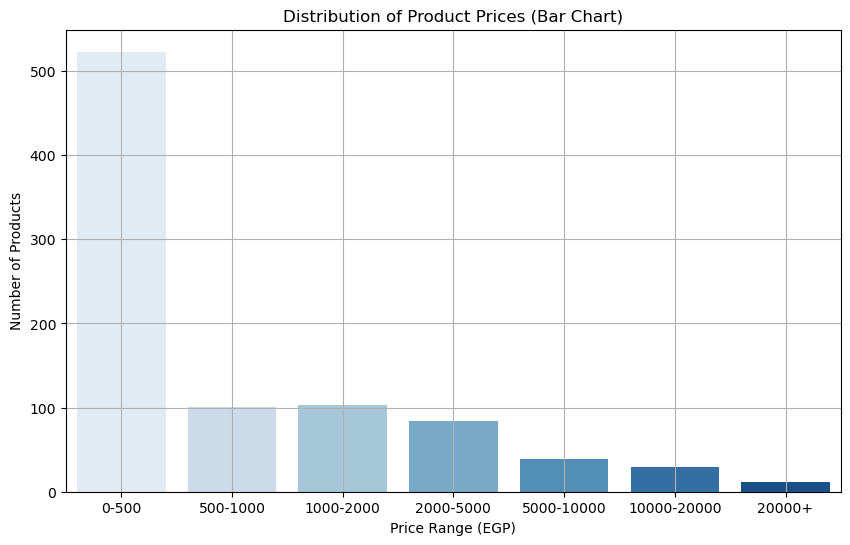

In [80]:
price_range_counts = df['price_range'].value_counts().sort_index()

plt.figure(figsize=(10,6))
sns.barplot(x=price_range_counts.index, y=price_range_counts.values, palette='Blues')
plt.title('Distribution of Product Prices (Bar Chart)')
plt.xlabel('Price Range (EGP)')
plt.ylabel('Number of Products')
plt.grid(True)
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_22644\3059177163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price', y='name', data=top_10, palette='magma')


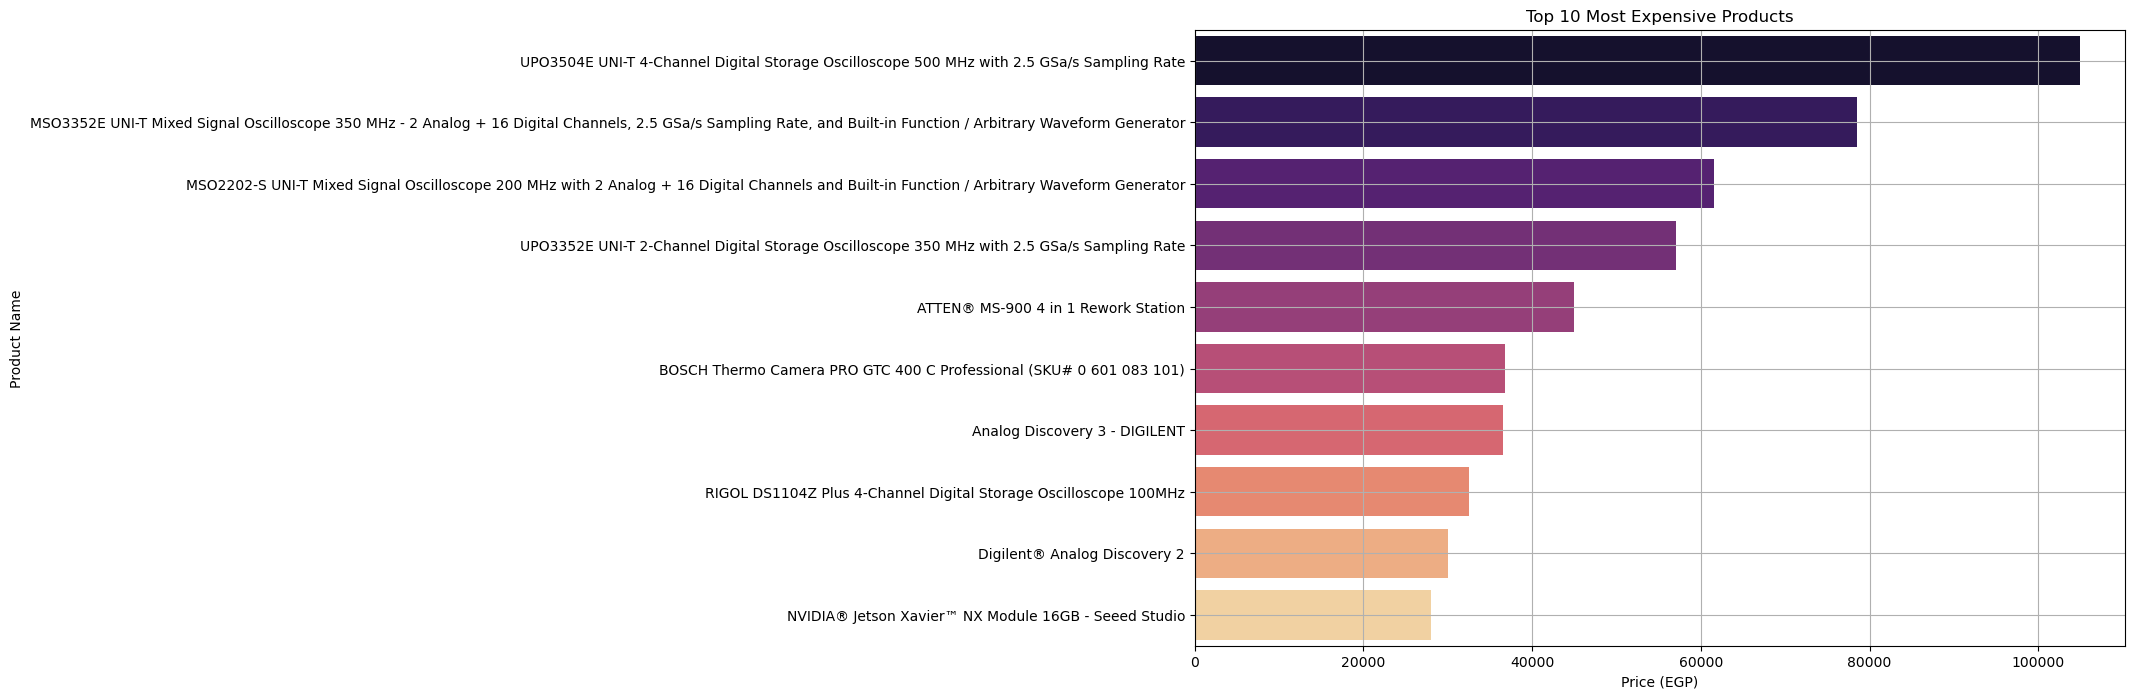

In [86]:
top_10 = df.sort_values('price', ascending=False).head(10)

plt.figure(figsize=(12,8))
sns.barplot(x='price', y='name', data=top_10, palette='magma')
plt.title('Top 10 Most Expensive Products')
plt.xlabel('Price (EGP)')
plt.ylabel('Product Name')
plt.grid(True)
plt.show()


stats = {
    'Minimum Price': df['price'].min(),
    'Maximum Price': df['price'].max(),
    'Average Price': df['price'].mean()
}

C:\Users\pc\AppData\Local\Temp\ipykernel_22644\2351894257.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(stats.keys()), y=list(stats.values()), palette='coolwarm')


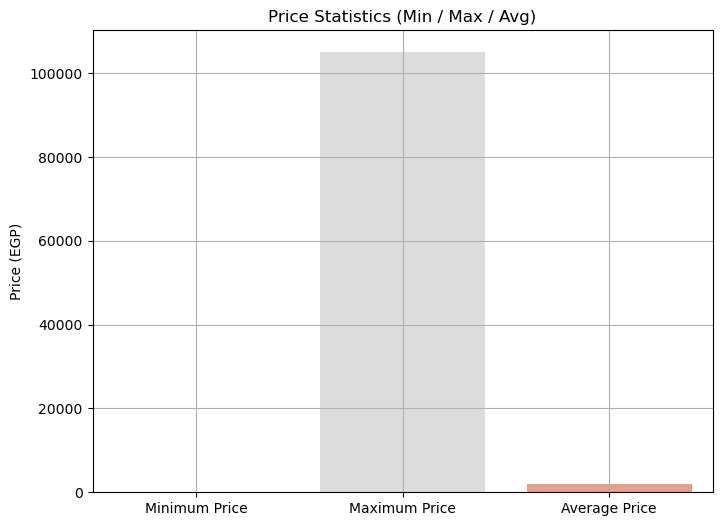

In [85]:
plt.figure(figsize=(8,6))
sns.barplot(x=list(stats.keys()), y=list(stats.values()), palette='coolwarm')
plt.title('Price Statistics (Min / Max / Avg)')
plt.ylabel('Price (EGP)')
plt.grid(True)
plt.show()
outliers = df[df['price'] > 10000]

C:\Users\pc\AppData\Local\Temp\ipykernel_22644\3345372918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outliers['name'], y=outliers['price'], palette='rocket')


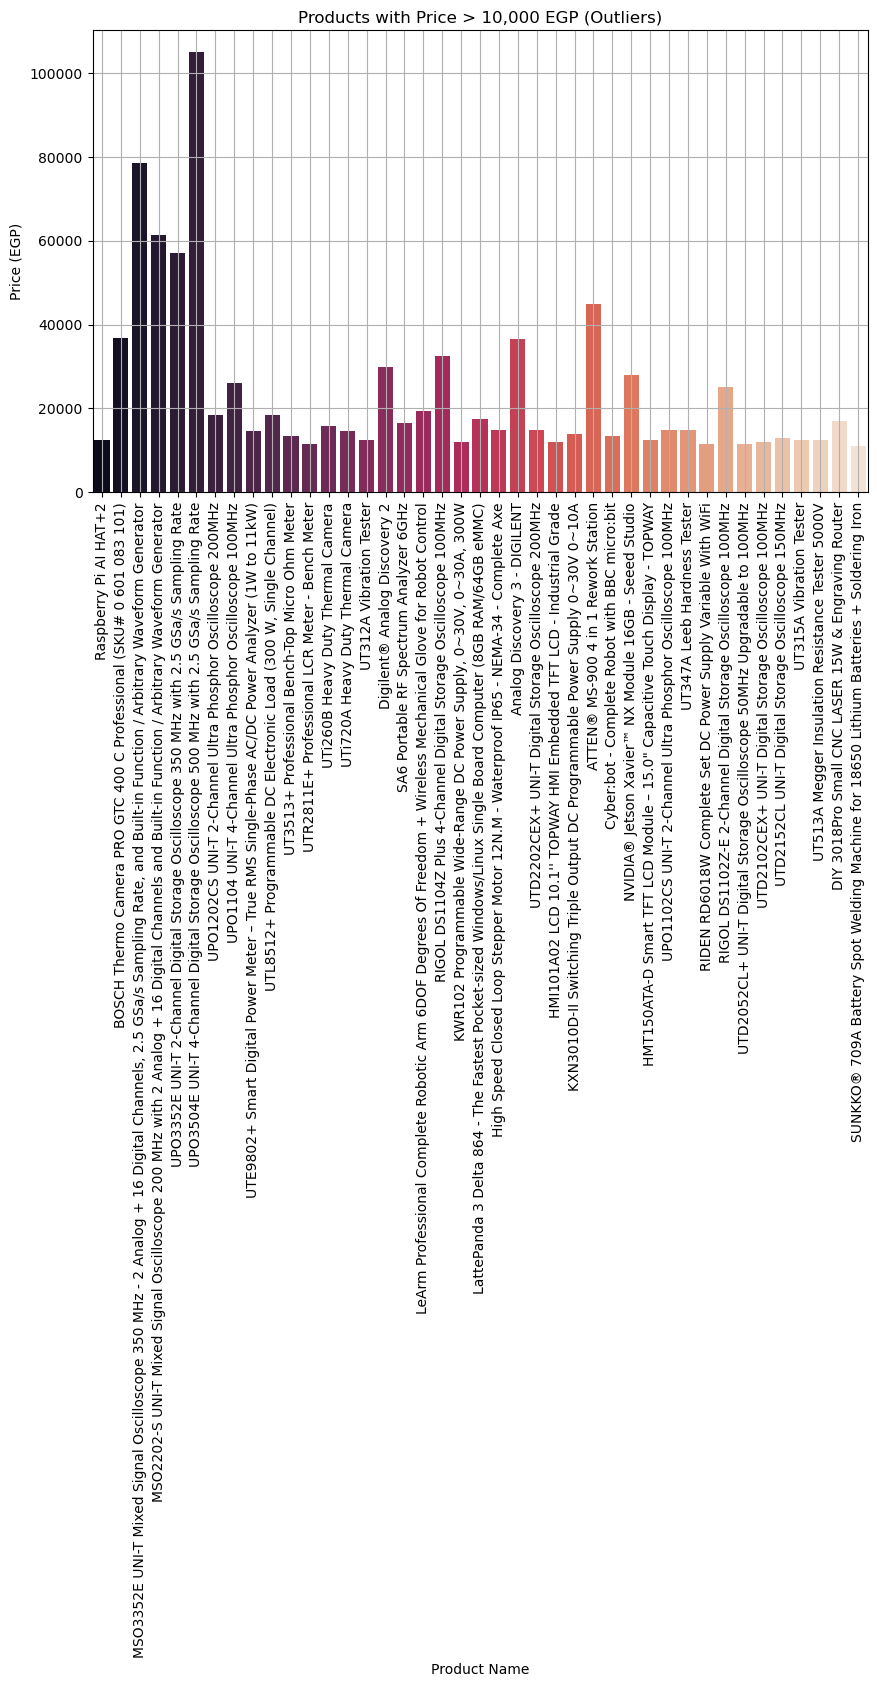

In [84]:
plt.figure(figsize=(10,6))
sns.barplot(x=outliers['name'], y=outliers['price'], palette='rocket')
plt.title('Products with Price > 10,000 EGP (Outliers)')
plt.xticks(rotation=90)
plt.xlabel('Product Name')
plt.ylabel('Price (EGP)')
plt.grid(True)
plt.show()

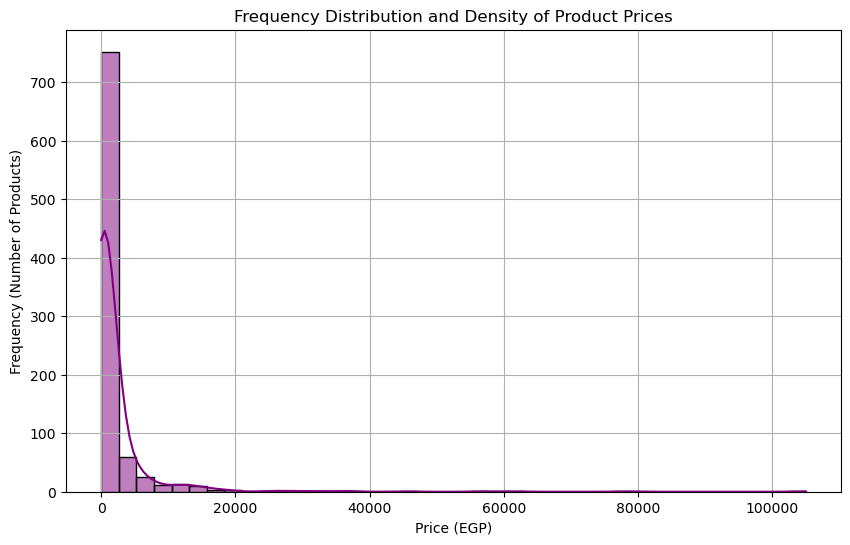

In [99]:

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=40, kde=True, color='purple')

plt.title('Frequency Distribution and Density of Product Prices')
plt.xlabel('Price (EGP)')
plt.ylabel('Frequency (Number of Products)')
plt.grid(True)
plt.show()